### 04. Exploring the properties of the Duque+2021 catalog

This notebook explores the use of HEALPy with eROSITA-DE all sky survey data.


**Author**: Soumya Shreeram <br/>
**Date created**: 28th April 2022 <br/>
**Last edited**: tbu <br/>

In [1]:
# astropy modules
import astropy.units as u
import astropy.io.fits as fits

from astropy.table import Table, Column, join
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM, z_at_value

import numpy as np

# system imports
import os
import sys
import importlib as ib
import glob
import gzip
import copy

# plotting imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

import seaborn as sns
import pandas as pd

import healpy as hp
from healpy.newvisufunc import projview, newprojplot

In [2]:
mpl.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : 'serif',
        'weight' : 'medium',
        'size'   : 16}
mpl.rc('font', **font)

bright_colors = sns.color_palette("bright")

In [3]:
import filaments as fo

Reloading the imports while developing modules

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
base_dir = "/data53s/shreeram/Filament_stacking"
code_dir = f"{base_dir}/code"
image_dir = f"{base_dir}/images"
data_dir = f"{base_dir}/data"

Initiating one of the filament catalogues that will be used later for stacking purposes.

In [6]:
this_fil_duque21 = fo.Filaments(filament_catalogue_name='Duque_2021_SDSS')
plot_obj_duque21 = fo.DoPlotFilaments(this_fil_duque21)

# open the filament catalogue
fil_table, ra_og, dec_og = this_fil_duque21.open_fil_cat()

In [139]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))

n, _, _ = ax.hist(fil_table['unc'], bins=100, color='k', alpha=0.8)

ymin, ymax = np.min(n), np.max(n)+1e3
cut_off_x = np.percentile(fil_table['unc'], 40)
ax.vlines(cut_off_x, ymin=ymin, ymax=ymax, colors='r', 
          linestyle='solid', linewidth=2)

fo.set_labels(ax, "Estimated uncertainty of detection (deg)", 'counts', legend=False)
fo.set_as_white(ax)

INFO:Filaments:Default param 'which_redshifts=lowz'  


INFO:DoPlotFilaments: Plotting Duque_2021_SDSS on the all sky projection.
INFO:Filaments:Default param 'which_redshifts=lowz'  


<MollweideAxesSubplot:title={'center':'BOSS: z=0.1-0.5\n'}>

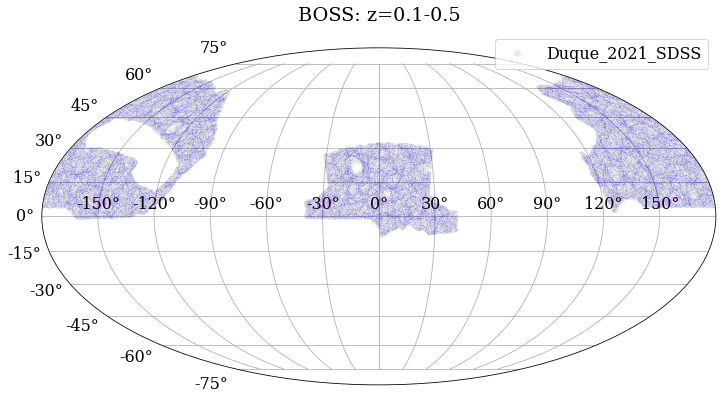

In [10]:
plot_obj_duque21.plot_filaments_on_sky(color=bright_colors[4])

To find the individual filaments on each redshift slice the following:
(a) A binary HEALPix map of nside = 256 is created with value of 0 everywhere 

(b) The values of the pixels close to a filament point in the catalogue are changed to 1,

(c) The skeleton of this map is extracted,

(d) Pixels in the skeleton are divided into filaments, ends, or intersections depending on the number of neighbours, and 

(e) Filaments are considered to be the connected set of pixels between intersections or ends.

256 786432


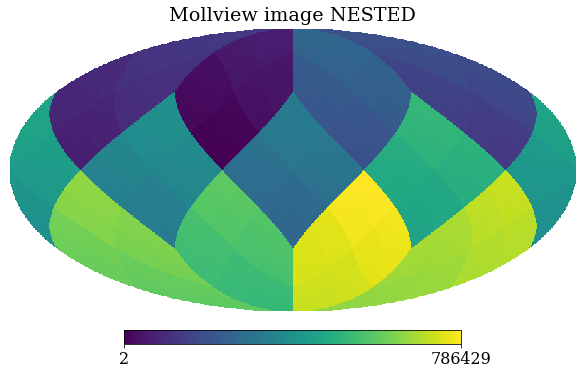

In [147]:
NSIDE = 256
NPIX = hp.nside2npix(NSIDE)
cmap = copy.copy(mpl.cm.get_cmap("viridis"))

m = np.arange(NPIX)
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="mollweide")
hpx_map = hp.mollview(m, nest=True, title="Mollview image NESTED", 
                      return_projected_map=True, hold=True, cmap=cmap)
fig.patch.set_facecolor('white')
print(NSIDE, NPIX)

In [10]:
def ra_dec_2_theta_phi(ra,dec):
    c = SkyCoord(ra=ra, dec=dec, frame='icrs', unit=u.deg)
    phi, theta = c.ra.wrap_at(180*u.deg).radian, 0.5 * np.pi - c.dec.radian
    return theta, phi

def produce_filament_map(NSIDE, ra, dec, return_pixel_idx=False):
    "Function to generate the filament map as accepted by healpy"
    NPIX = hp.nside2npix(NSIDE)
    filament_map = np.zeros(NPIX)

    theta, phi = ra_dec_2_theta_phi(ra.value, dec.value)
    pixel_idx = hp.pixelfunc.ang2pix(NSIDE, theta, phi, nest=True, lonlat=False)
    filament_map[pixel_idx] = 1
    if return_pixel_idx:
        return filament_map, pixel_idx
    else:
        return filament_map

In [148]:
theta, phi = ra_dec_2_theta_phi(ra.value, dec.value)

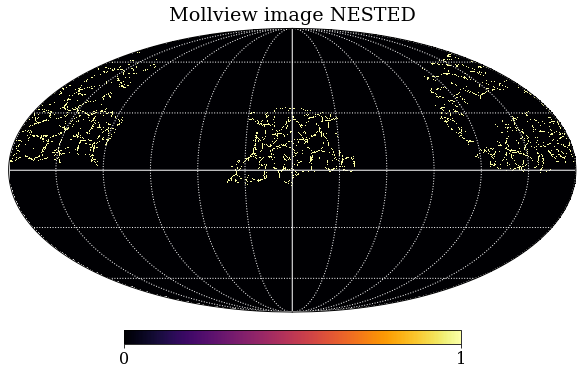

In [198]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111,  projection="mollweide")

filament_map = produce_filament_map(NSIDE, ra, dec)
hp.mollview(filament_map, nest=True, title="Mollview image NESTED",\
                                     cmap=cmap, hold=True, fig=1)
hp.graticule(color='w')
fig.patch.set_facecolor('white')


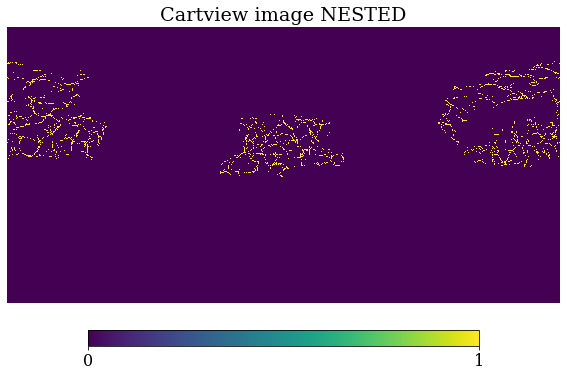

In [150]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111)

projected_cart_map = hp.cartview(filament_map, fig=1, nest=True, title="Cartview image NESTED",\
                                     cmap=cmap, hold=True, return_projected_map=True)
fig.patch.set_facecolor('white')

<MollweideAxesSubplot:>

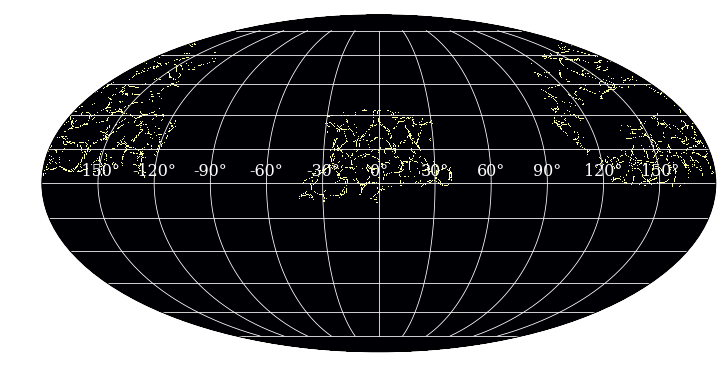

In [151]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="mollweide")

lon = np.linspace(-np.pi, np.pi, projected_cart_map.shape[1])
lat = np.linspace(-np.pi/2., np.pi/2., projected_cart_map.shape[0])
Lon,Lat = np.meshgrid(lon,lat)

ax.pcolormesh(Lon, Lat, projected_cart_map, cmap='inferno', shading='auto')
ax.grid(True, color='w')
fo.set_as_white(ax)

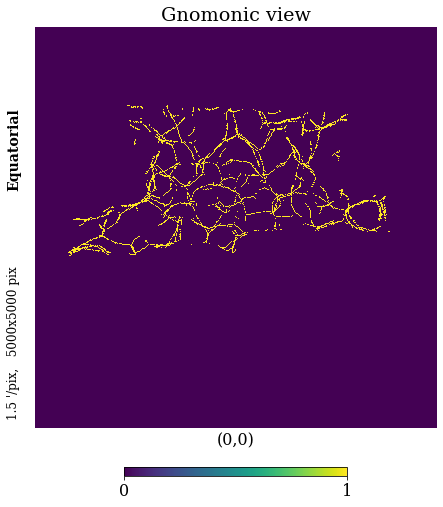

In [202]:
fig = plt.figure(figsize=(8,9))
ax = plt.subplot(111)

hp.gnomview(filament_map, fig=1, coord='C',
           xsize=5000, ysize=5000, nest=True, hold=True)
fo.set_labels(ax, "RA", "dec", title="Using gnomview", legend=False)
ax.set_title("Using gnomview", color='w')
fig.patch.set_facecolor('white')

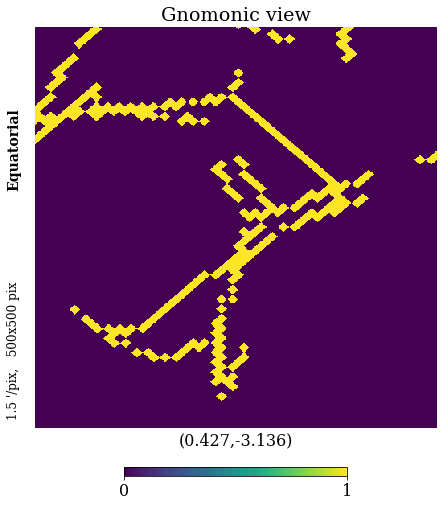

In [153]:
fig = plt.figure(figsize=(8,9))
ax = plt.subplot(111)

hp.gnomview(filament_map, fig=1, rot=[theta[0], phi[0], 0 ], coord='C',
           xsize=500, ysize=500, nest=True, hold=True)
fo.set_labels(ax, "RA", "dec", title="Using gnomview", legend=False)
ax.set_title("Using gnomview", color='w')
fig.patch.set_facecolor('white')

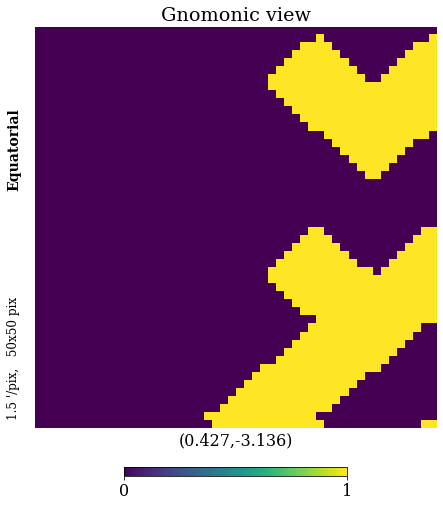

In [154]:
fig = plt.figure(figsize=(8,9))
ax = plt.subplot(111)

hp.gnomview(filament_map, fig=1, rot=[theta[0], phi[0], 0 ], coord='C',
           xsize=50, ysize=50, nest=True, hold=True)
fo.set_labels(ax, "RA", "dec", title="Using gnomview", legend=False)
ax.set_title("Using gnomview", color='w')
fig.patch.set_facecolor('white')

Text(0.5, 1.0, 'Using projview')

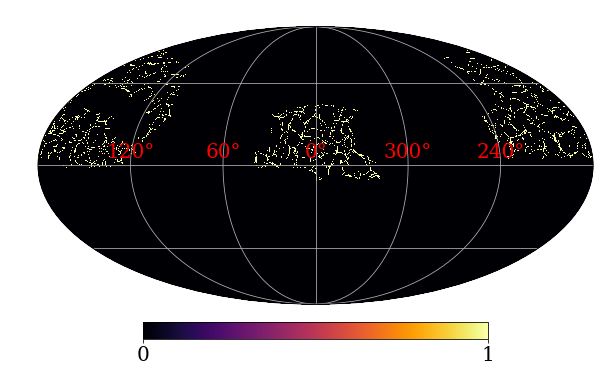

In [171]:
cmap = copy.copy(mpl.cm.get_cmap("inferno"))

projview(filament_map, nest=True, graticule=True, graticule_labels=True,
         title="Mollview image NESTED", projection_type="mollweide",
         cmap=cmap, hold=True, latitude_grid_spacing=45, coord='C',
         xtick_label_color='r', ytick_label_color='w',
         fontsize={
                "xlabel": 20,
                "ylabel": 20,
                "xtick_label": 20,
                "ytick_label": 20,
                "title": 20,
                "cbar_label": 20,
                "cbar_tick_label": 20,
            }, flip='geo')
plt.title("Using projview", color='w')

### 2. Checking out the neighbours

Effect of the resultion of the map on the neighbouring pixel count.

In [15]:
def get_how_many_neighbours(NSIDE, ra, dec):
    filament_map, pixel_idx = produce_filament_map(NSIDE, ra, dec, return_pixel_idx=True)

    neighbours = hp.pixelfunc.get_all_neighbours(NSIDE, pixel_idx, nest=True)
    vals_neighbours = np.zeros(neighbours.shape)
    vals_neighbours = filament_map[neighbours]
    return vals_neighbours

We now check how many neighbours each cell has. For example here, the distribution of the 8 nearest pixels around a given pixel that has a non zero filament value is shown:

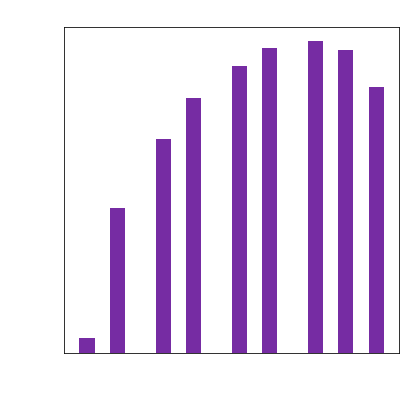

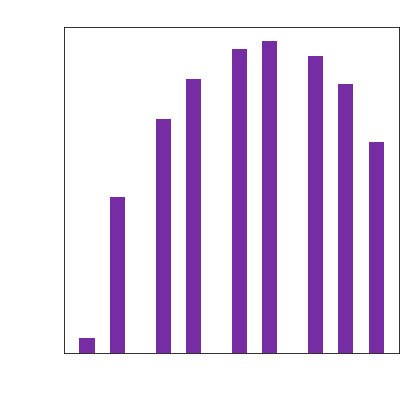

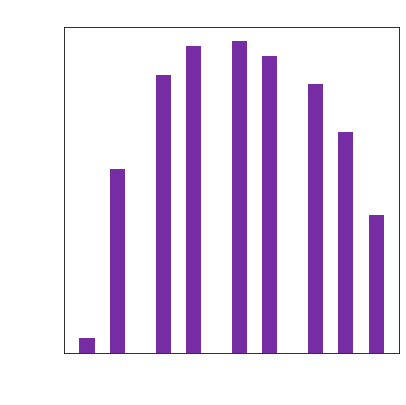

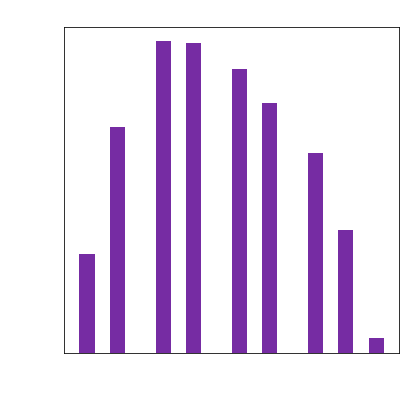

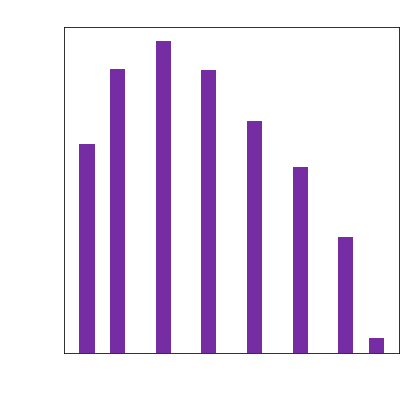

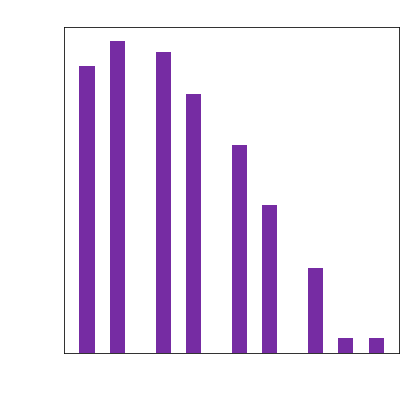

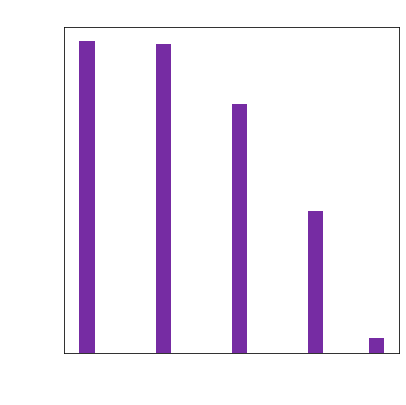

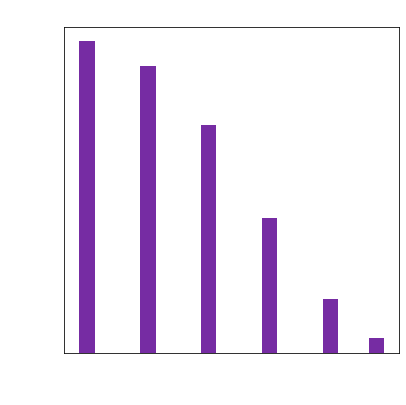

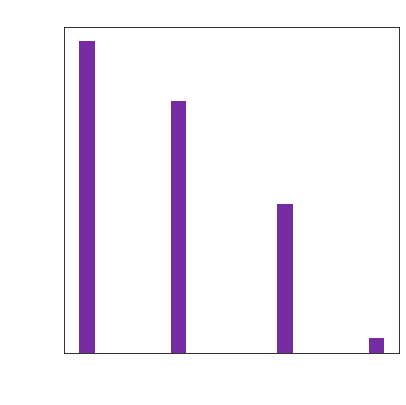

In [155]:
for nside in [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]:
    vals_neighbours = get_how_many_neighbours(nside, ra, dec)
    fig, ax = plt.subplots(1, 1, figsize=(6,6))
    ax.hist(np.sum(vals_neighbours, axis=0), bins=20, color='#762ca3')
    fo.set_labels(ax, "Number of filament neighbours", "Counts", title=f"NSIDE={nside}", legend=False)
    ax.set_yscale("log")
    fo.set_as_white(ax)

### Get the skeleton of the projected map
Let's try to classify the filament points based on the number of neighbours

In [16]:
from skimage.morphology import skeletonize
from skimage import data
from skimage.util import invert

In [156]:
skeleton = skeletonize(projected_cart_map.data)

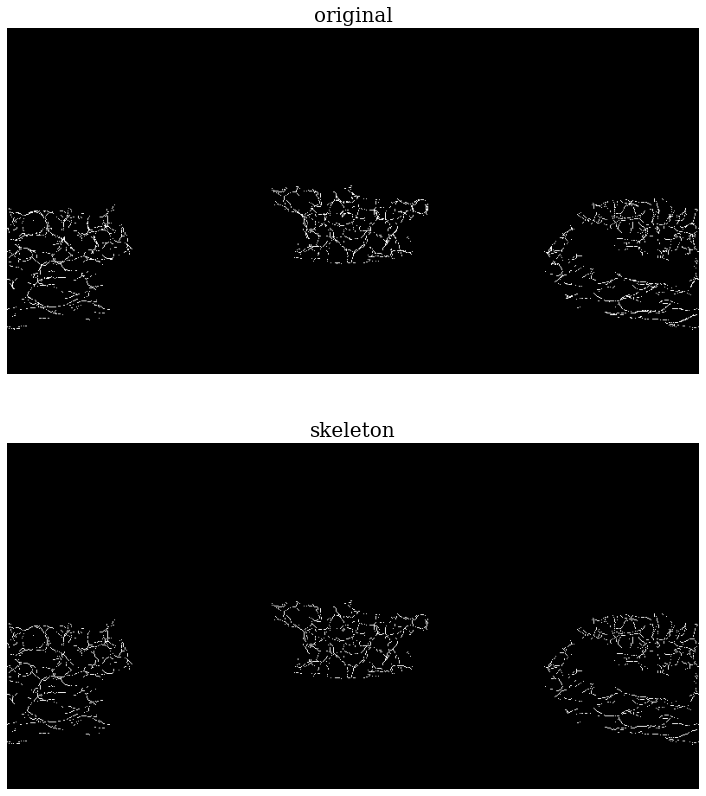

In [157]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 14),
                         sharex=True, sharey=True)
fig.patch.set_facecolor('white')
ax = axes.ravel()

ax[0].imshow(projected_cart_map.data, cmap=plt.cm.gray)
ax[0].axis('off')
ax[0].set_title('original', fontsize=20)

ax[1].imshow(skeleton, cmap=plt.cm.gray)
ax[1].axis('off')
ax[1].set_title('skeleton', fontsize=20)

plt.show()


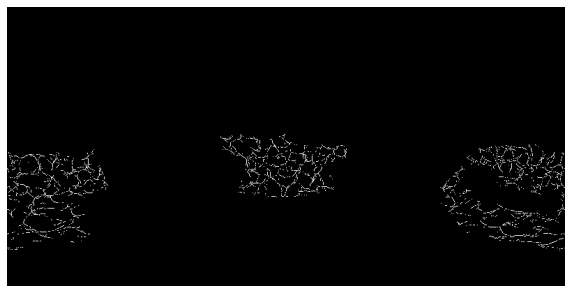

In [158]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10),
                         sharex=True, sharey=True)
fig.patch.set_facecolor('white')

ax.imshow(skeleton, cmap=plt.cm.gray)
ax.axis('off')
plt.savefig(f'{image_dir}/filament_skeleton.png', dpi=300)

plt.show()

### Reconstructing the 1-D healpy map array from the 2-D projected array

In [160]:
proj_fil_skeleton_map = np.zeros(skeleton.shape)

# changing the skeleton map into a 1/0 array
proj_fil_skeleton_map[skeleton] = 1

In [161]:
np.sum(proj_fil_skeleton_map), np.sum(projected_cart_map)

(3518.0, 3989.0)

In [162]:
proj = hp.projector.CartesianProj(
    coord='C', 
    xsize=proj_fil_skeleton_map.shape[1], ysize=proj_fil_skeleton_map.shape[0])

x, y = hp.projector.CartesianProj.ang2xy(proj, theta=theta, phi=phi, lonlat=False)

In [163]:
i, j = hp.projector.CartesianProj.xy2ij(proj, x=x, y=y)

In [176]:
filament_skeleton_map = np.zeros(NPIX)
pixel_idx = hp.pixelfunc.ang2pix(NSIDE, theta, phi, lonlat=False)
pixel_idx_nest = hp.pixelfunc.ring2nest(NSIDE, pixel_idx)

filament_skeleton_map[pixel_idx_nest] = proj_fil_skeleton_map[i, j]

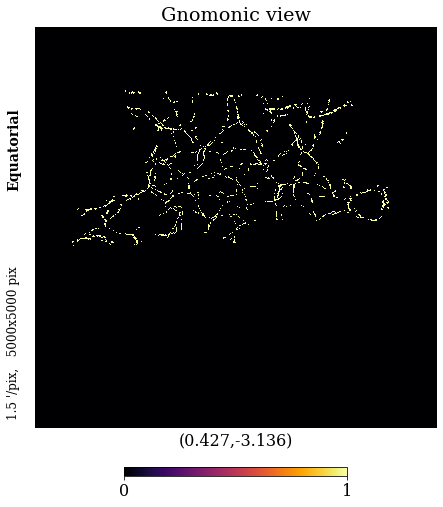

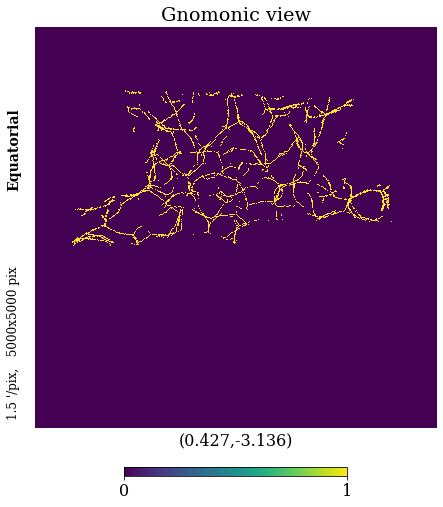

In [191]:
# skeleton filament map
fig, ax = plt.subplots(1, 1, figsize=(8,9))
hp.gnomview(filament_skeleton_map, rot=[theta[0], phi[0], 0 ], coord='C',
           xsize=5000, ysize=5000, nest=True, hold=True,
            cmap= copy.copy(mpl.cm.get_cmap("inferno")) )
fo.set_labels(ax, "RA", "dec", title="Skeleton gnomview", legend=False)
fig.patch.set_facecolor('white')

# original filament map
fig, ax = plt.subplots(1, 1, figsize=(8,9))
hp.gnomview(filament_map, fig=1, rot=[theta[0], phi[0], 0 ], coord='C',
           xsize=5000, ysize=5000, nest=True, hold=True)
fo.set_labels(ax, "RA", "dec", title="Original gnomview", legend=False)
fig.patch.set_facecolor('white')

/home/shreeram/miniconda3/envs/eroconda/lib/python3.7/site-packages/healpy/projaxes.py:543: UserWarning: 0.0 180.0 -180.0 180.0
  pmin / dtor, pmax / dtor, mmin / dtor, mmax / dtor
/home/shreeram/miniconda3/envs/eroconda/lib/python3.7/site-packages/healpy/projaxes.py:658: UserWarning: The interval between parallels is 30 deg -0.00'.
  vdeg, varcmin
/home/shreeram/miniconda3/envs/eroconda/lib/python3.7/site-packages/healpy/projaxes.py:666: UserWarning: The interval between meridians is 30 deg -0.00'.
  vdeg, varcmin


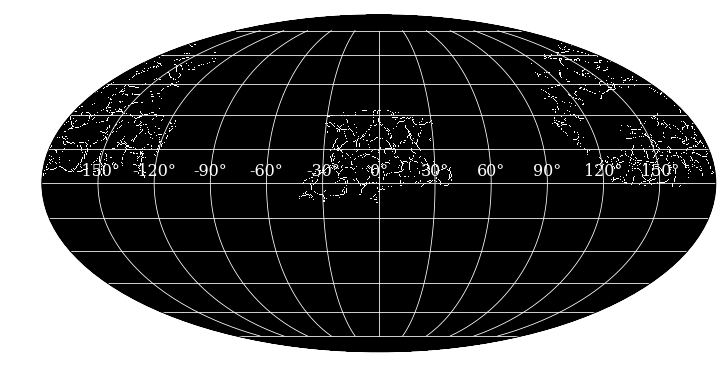

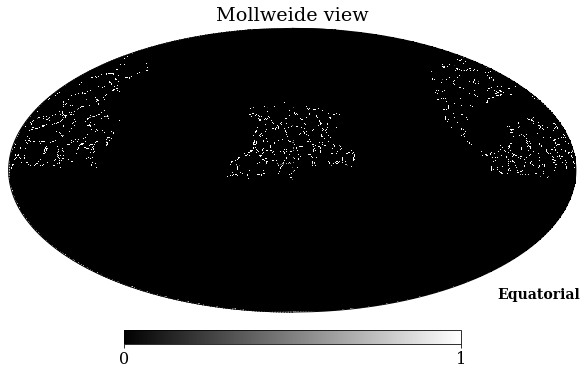

In [195]:
# orginal skeleton plot
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="mollweide")

lon = np.linspace(-np.pi, np.pi, projected_cart_map.shape[1])
lat = np.linspace(-np.pi/2., np.pi/2., projected_cart_map.shape[0])
Lon,Lat = np.meshgrid(lon,lat)

ax.pcolormesh(Lon, Lat, skeleton, cmap=plt.cm.gray, shading='auto')

ax.grid(True, color='w')
fo.set_as_white(ax)

# Reconstructed skeleton plot
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="mollweide")

hp.mollview(filament_skeleton_map, fig=1, rot=[theta[0], phi[0], 0 ], 
            coord='C',nest=True, hold=True, cmap=plt.cm.gray)
hp.graticule()
fo.set_labels(ax, "RA", "dec", title="Using gnomview", legend=False)
ax.set_title("Using gnomview", color='w')
fig.patch.set_facecolor('white')

-471.0

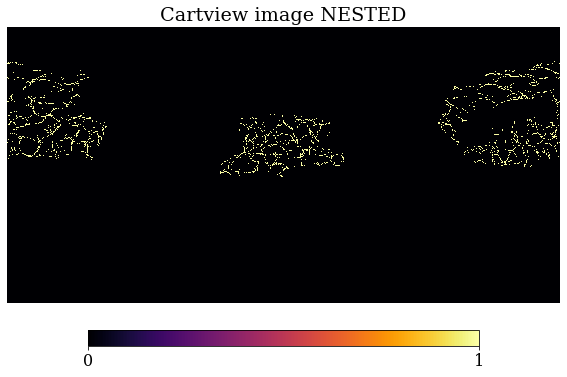

In [196]:
# test block to see if we can obtain the same projected array that we started off with
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111)

test_projected_cart_map = hp.cartview(filament_map, fig=1, nest=True, title="Cartview image NESTED",\
                                     cmap=cmap, hold=True, return_projected_map=True)
fig.patch.set_facecolor('white')

np.sum(proj_fil_skeleton_map-test_projected_cart_map)